In [1]:
# %%
from __future__ import print_function

import numpy as np 
import matplotlib.pyplot as plt
import openpathsampling as paths
import os
# we use the %run magic because this isn't in a package
import torch 
import aimmd 
import sys

current_directory = os.path.dirname(os.path.abspath(os.getcwd()))
# Add the current directory to sys.path
sys.path.append(current_directory)

# Get the parent directory
parent_directory = os.path.abspath(os.path.join(current_directory, os.pardir))
parent_parent_directory = os.path.abspath(os.path.join(parent_directory, os.pardir))
# Add the parent directory to sys.path
sys.path.append(parent_directory)
sys.path.append(parent_parent_directory)

import TIS_AIMMD_toy_framework as TAI
from TIS_AIMMD_toy_framework import potential_0, TIS_AIMMD_setup, read_config
import openpathsampling.engines.toy as toys
from functools import reduce
import importlib
importlib.reload(TAI)

<module 'TIS_AIMMD_toy_framework' from '/Users/rbreeba/Documents/PhD/-RE-TIS-AIMMD/TIS_AIMMD_toy_framework/__init__.py'>

In [2]:
import openpathsampling.engines.toy as toys
settings = {"n_harmonics": 20,
            "rotation_degrees": 0,
            "scale": 1}
pes = TAI.potential_switch("FacePotential", settings)
n_harmonics = pes.n_harmonics


123
pot dimensions without oscillators: 2
harmonic oscillators omegas:
array([0.        , 0.        , 1.        , 1.5       , 7.57175348,
       4.28911468, 3.81481163, 6.41051815, 7.75575176, 5.38485168,
       9.84611359, 7.47863791, 5.84745521, 5.13694015, 4.74542413,
       7.83239766, 5.50857796, 2.47742317, 5.18435404, 7.90396325,
       3.45993384, 3.40361405])


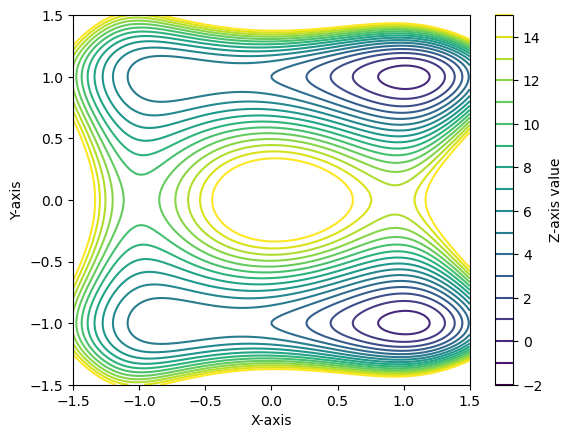

In [3]:
x = np.linspace(pes.extent[0],pes.extent[1],300)
y = np.linspace(pes.extent[2],pes.extent[3],300)
x_2d, y_2d, U = pes.plot_2d_pes(x,y)
# Step 2: Create the colormap
colormap = 'plasma'  # You can choose a different colormap from Matplotlib's colormaps

# Step 3: Generate the 2D image

plt.figure()
plt.contour(x_2d,y_2d,U, levels = pes.levels)
plt.colorbar(label='Z-axis value')  # Add a colorbar to show the intensity scale
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()


In [4]:

integ = toys.LangevinBAOABIntegrator(dt=0.02, temperature=1, gamma=10)
options={
    'integ' : integ,
    'n_frames_max' : 5000,
    'n_steps_per_frame' : 1
}
toy_eng = toys.Engine(
    options=options,
    topology=pes.topology
)
toy_eng.initialized = True

template = pes.template(toy_eng)
toy_eng.current_snapshot = template
paths.PathMover.engine = toy_eng

# Collective variables to define the states
opA = paths.CoordinateFunctionCV(name="opA", f=pes.stable_interface_function, center=pes.state_A)
opB = paths.CoordinateFunctionCV(name="opB", f=pes.stable_interface_function, center=pes.state_B)

# State volumes in CV space
stateA = paths.CVDefinedVolume(opA, 0.0, pes.state_boundary).named('StateA')
stateB = paths.CVDefinedVolume(opB, 0.0, pes.state_boundary).named('StateB')
#

In [5]:
# Fake an initial trajectory
init_AB = paths.Trajectory(pes.simple_initial_path(1000,toy_eng))


## here is the AIMMD specific part where the commitor model is initialized

In [6]:
# collective variable to transform OPS snapshots to model descriptor space,
# i.e. the space in which the model learns
descriptor_transform = paths.FunctionCV('descriptor_transform', lambda s: s.coordinates[0], cv_wrap_numpy_array=True).with_diskcache()
descriptor_dim = pes.n_dims_pot+pes.n_harmonics

In [7]:
import torch.nn.functional as F
import torch.nn as nn

Hidden_layers = [512, 256]

activation =  torch.nn.ReLU()

dropout= [0.1, 0.05]
n_unit_layers = [descriptor_dim] + Hidden_layers

modules = []
for i in range(len(Hidden_layers)):
    modules += [aimmd.pytorch.networks.FFNet(n_in=n_unit_layers[i],
                                        n_hidden = [n_unit_layers[i+1]],
                                        activation = activation,
                                        dropout = {"0":dropout[i]})]


 # this step below does an internal linear layer from the final hidden layer size to the final n_out=1 output.
torch_model = aimmd.pytorch.networks.ModuleStack(n_out=1,
                                                 modules = modules)

# move model to GPU if CUDA is available
use_gpu = False
if torch.cuda.is_available() and use_gpu:
    torch_model = torch_model.to('cuda')
    print("using cuda")
elif torch.backends.mps.is_available() and use_gpu:
    torch_model = torch_model.to('mps')
else: 
    torch_model = torch_model.to("cpu")

# choose and initialize an optimizer to train the model
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)

In [8]:
# create aimmd storage
aimmd_store = aimmd.Storage('aimmd_storage_{}.h5'.format(pes.__repr__()), "w")

In [9]:
# we take an ExpectedEfficiencyPytorchRCModel,
# this RCmodel scales the learning rate by the expected efficiency factor (1 - n_TP_true / n_TP_expected)**2
model = aimmd.pytorch.EEScalePytorchRCModel(nnet=torch_model,
                                            optimizer=optimizer,
                                            states=[stateA, stateB],
                                            ee_params={'lr_0': 1e-3,  # lr = lr_0 * (1 - n_TP_true / n_TP_expected)**2
                                                       'lr_min': 5e-5,  # do not train if lr < lr_min
                                                       'epochs_per_train': 5,  # train for 1 epochs every time we train
                                                       'interval': 5,  # attempt to train after every 3rd MCStep
                                                       'window': 75,  # average expected efficiency factor over 100 MCSteps
                                                       },
                                            descriptor_transform=descriptor_transform,  # the function transforming snapshots to descriptors
                                            loss=None,  # if loss=None it will choose either binomial or multinomial loss, depending on the number of model outputs,
                                                        # but we could have also passed a custom loss function if we wanted to
                                            cache_file=aimmd_store,  # cache file for density collector
                                            )



In [10]:
trainset = aimmd.TrainSet(n_states=2)

In [11]:
trainhook = aimmd.ops.TrainingHook(model, trainset)
storehook = aimmd.ops.AimmdStorageHook(aimmd_store, model, trainset)
densityhook = aimmd.ops.DensityCollectionHook(model)

In [12]:
selector = aimmd.ops.RCModelSelector(model=model,  # always takes a RCModel
                                     # we can greatly speed up rejecting/accepting trial TPS by passing the list of states
                                     # this enables testing if a trial TP is even a TP and calculating the potentially costly
                                     # transformation from Cartesian to descriptor space only if neccessary
                                     # if we are lazy and know that the transformation is fast we can also explicitly pass None
                                     states=[stateA, stateB],
                                     # new shooting points are selected with p_sel(SP) ~ p_lorentz(model.z_sel(SP))
                                     # could also choose 'gaussian'
                                     distribution='lorentzian',
                                     # softness of the selection distribtion,
                                     # lower values result in a sharper concentration around the predicted transition state,
                                     # higher values result in a more uniform selection
                                     scale=1.0,
                                    )

In [13]:
# velocity randomizer setup
beta = integ.beta
modifier = paths.RandomVelocities(beta=beta, engine=toy_eng)
# shooting strategy: TwoWayShooting
tw_strategy = paths.strategies.TwoWayShootingStrategy(modifier=modifier, selector=selector, engine=toy_eng, group='TwoWayShooting')
# transition network, tells us which transitions to sample
network = paths.TPSNetwork.from_states_all_to_all([stateA, stateB])
# move scheme, tells us how to do the sampling
move_scheme = paths.MoveScheme(network=network)
move_scheme.append(tw_strategy)
# this should always be the last added strategy for custom move_schemes, it sorts all previously appended strats when building the tree
move_scheme.append(paths.strategies.OrganizeByMoveGroupStrategy())
move_scheme.build_move_decision_tree()

In [14]:
# %%
initial_conditions = move_scheme.initial_conditions_from_trajectories(init_AB)

# %%
initial_conditions.sanity_check()


No missing ensembles.
No extra ensembles.


In [15]:
# %%
storage = paths.Storage("simple_store.nc", "w", template=template)
storage.save(toy_eng)
storage.save(move_scheme)
storage.save(network)


(store.networks[TransitionNetwork] : 1 object(s),
 13,
 162889660336184934598774742184718501874)

In [16]:
for s in initial_conditions.samples:
    print(s)

Sample(RepID: 0, Ens: <openpathsampling.ensemble.UnionEnsemble object at 0x3342793d0>, Trajectory[960])


In [17]:
sampler = paths.PathSampling(storage, move_scheme, initial_conditions)


In [18]:
sampler.attach_hook(trainhook)
sampler.attach_hook(storehook)
sampler.attach_hook(densityhook)

In [19]:

n_run = 500
sampler.run(n_run)

Working on Monte Carlo cycle number 500
Running for 27 minutes 57 seconds -  3.36 seconds per step
Estimated time remaining: 3 seconds


DONE! Completed 500 Monte Carlo cycles.


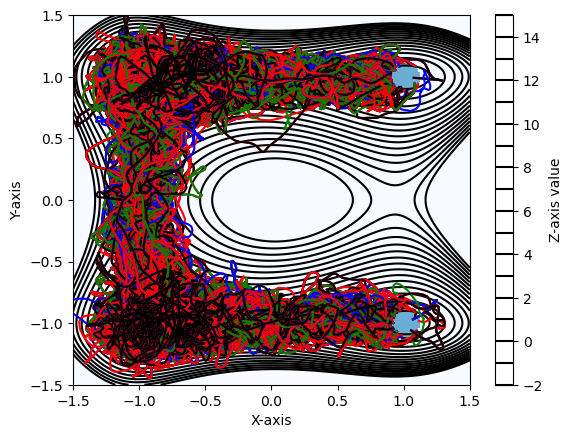

In [20]:
trajectories = [step.active[0].trajectory for step in storage.steps[::1]]
plt.figure()
plt.contour(x_2d,y_2d,U, pes.levels,colors='k')
plt.colorbar(label='Z-axis value') 
repcolordict = {0 : 'k-', 1 : 'r-', 2 : 'g-', 3 : 'b-', 4 : 'r-'}
for i, traj in enumerate(trajectories):
    plt.plot(traj.xyz[:,0,0], traj.xyz[:,0,1], repcolordict[i % 5])

states_plot = np.vectorize(TAI.CallableVolume(stateA))(x_2d, -y_2d)
states_plot += np.vectorize(TAI.CallableVolume(stateB))(x_2d, -y_2d)
plt.imshow(states_plot, extent=pes.extent, cmap="Blues",
            interpolation='nearest', vmin=0.0, vmax=2.0,
            aspect='auto')
 # Add a colorbar to show the intensity scale
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [21]:
from TIS_AIMMD_toy_framework import ToyAimmdVisualizer

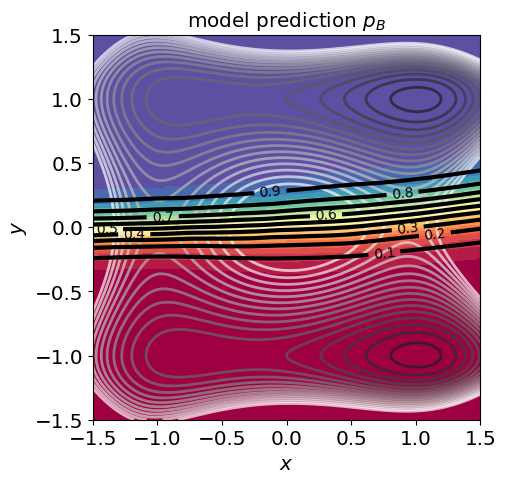

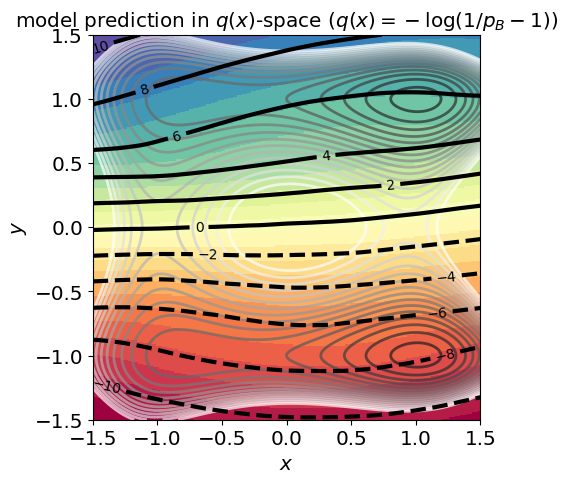

In [22]:
tav = ToyAimmdVisualizer(pes)
tav.committor_2d_projection(plot_model=model)
tav.q_space_2d_projection(model)

In [23]:
storage.close()
aimmd_store.close()